## This is going to be our attempt at understanding the data set at hands, specifically the RecipeDB_RecipeID_Cuisine.csv, RecipeID_CookingAction_List.xlsx, RecipeID_IngID.csv and the Ingredient data from CulinaryDB. 
### Here we analyse the dataset under:
#### -How many unique recipes total, and how many ingredients per recipe? What shall be the distribution of the ingredients' counts when plotted against the ingredient rank-frequency curve where the ranking is calculated by arranging the frequencies in decreasing order. 
#### -How many cuisines, and can we break the ingredient counts on the basis of the cuisines? 
#### -What's the distribution of ingredient counts per recipe?
#### -How many cooking actions per recipe?? And can we get the distribution of those Instruction counts?? And can we break it down on the basis of cuisine?(for the inset)
#### -Can we count how many recipes each ingredient appears in globally and on the basis of that take the first 10-15 and calculate their percentage global share and plot it in a pie chart?? 
#### -Can we count the frequency of each individual cooking action across all recipes?? And calculate the percentage global share of top 10-15 recipes and plot it in a pie chart?

## How many unique recipes total, and how many ingredients per recipe? What shall be the distribution of the ingredients' counts when plotted against the ingredient rank-frequency curve where the ranking is calculated by arranging the frequencies in decreasing order.

Total Unique Recipes: 118083

Ingredients Per Recipe Statistics:

count    118083.000000
mean          9.776208
std           3.960793
min           2.000000
25%           7.000000
50%           9.000000
75%          12.000000
max          38.000000
Name: ing_id, dtype: float64


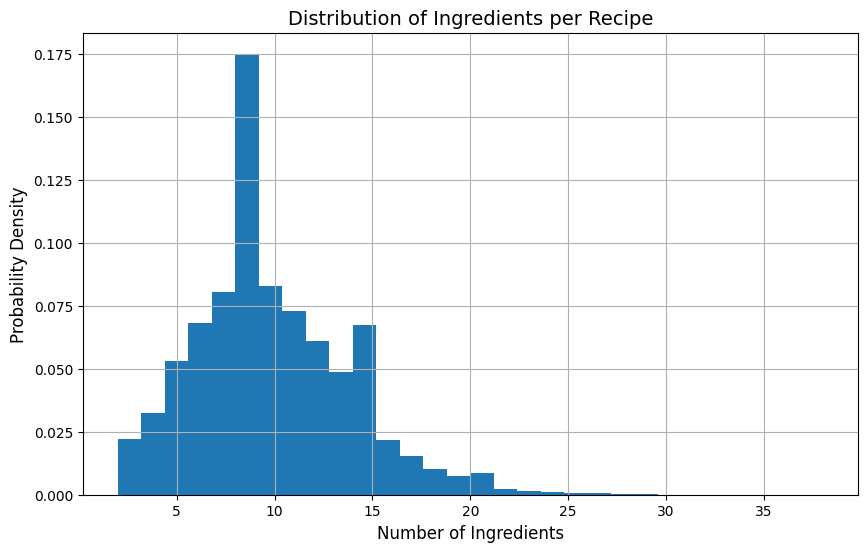

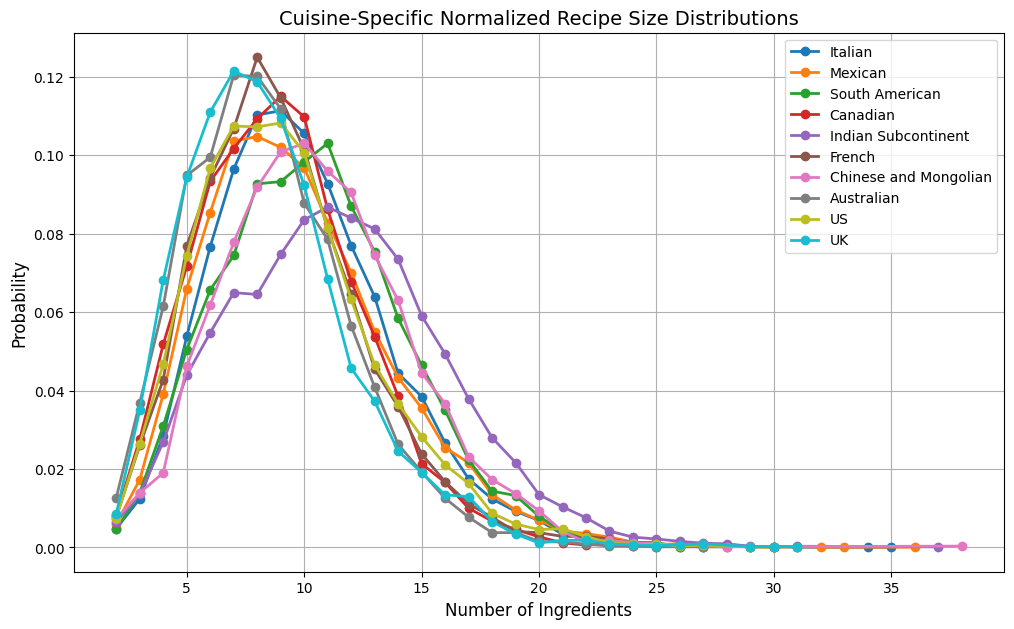

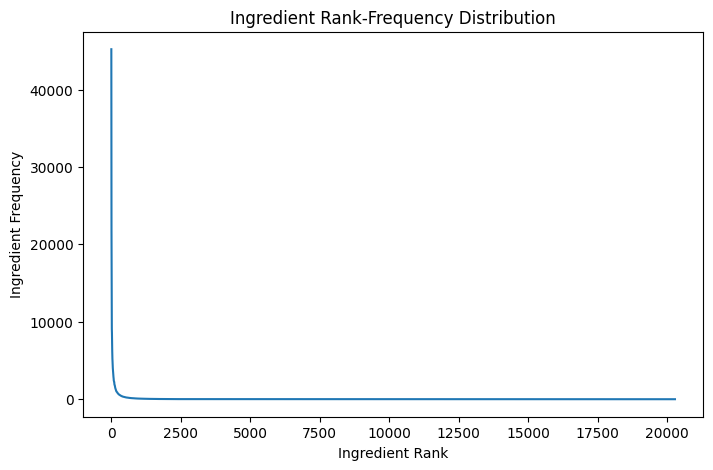

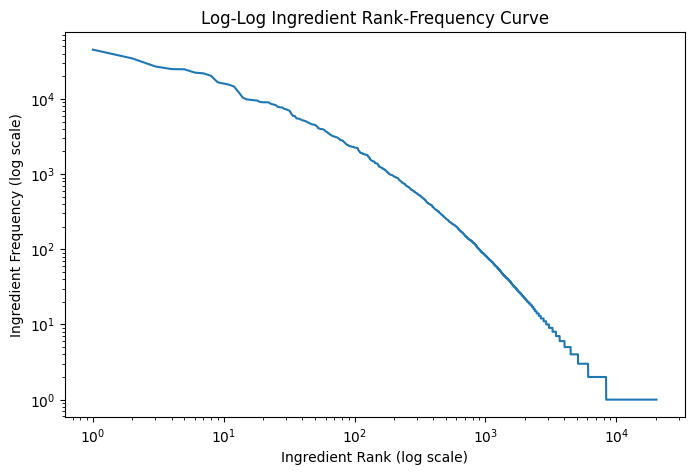


Top 10 Most Frequent Ingredient IDs:

ing_id
0    45206
1    34548
2    27013
4    24893
3    24773
5    22391
7    21861
6    20271
8    16625
9    15973
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# LOAD DATASETS

recipe_ing = pd.read_csv("../Datasets/RecipeID_Ing_ID.csv")
recipe_cuisine = pd.read_csv("../Datasets/RecipeDB_RecipeID_Cuisine.csv")

# TOTAL UNIQUE RECIPES

total_recipes = recipe_ing['recipe_no'].nunique()

print("Total Unique Recipes:", total_recipes)

# INGREDIENT COUNT PER RECIPE

ingredients_per_recipe = (
    recipe_ing.groupby('recipe_no')['ing_id']
    .count()
)

print("\nIngredients Per Recipe Statistics:\n")
print(ingredients_per_recipe.describe())

# DISTRIBUTION OF INGREDIENTS PER RECIPE

plt.figure(figsize=(10,6))

plt.hist(
    ingredients_per_recipe,
    bins=30,
    density=True
)

plt.xlabel("Number of Ingredients", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

plt.title(
    "Distribution of Ingredients per Recipe",
    fontsize=14
)

plt.grid(True)

plt.show()

# PREPARE DATA FOR CUISINE-SPECIFIC ANALYSIS

ingredients_per_recipe_df = (
    ingredients_per_recipe
    .reset_index()
)

ingredients_per_recipe_df.columns = [
    'Recipe_id',
    'Ingredient_Count'
]

# Merge with cuisine labels
merged_data = ingredients_per_recipe_df.merge(
    recipe_cuisine,
    on='Recipe_id'
)

# SELECT TOP 10 CUISINES

top_cuisines = (
    merged_data['Cuisine']
    .value_counts()
    .head(10)
    .index
)

# CUISINE-SPECIFIC NORMALIZED DISTRIBUTIONS

plt.figure(figsize=(12,7))

for cuisine in top_cuisines:

    cuisine_data = merged_data[
        merged_data['Cuisine'] == cuisine
    ]['Ingredient_Count']

    # Frequency distribution
    freq = cuisine_data.value_counts().sort_index()

    # Normalize into probabilities
    normalized_freq = freq.values / freq.values.sum()

    plt.plot(
        freq.index,
        normalized_freq,
        marker='o',
        linewidth=2,
        label=cuisine
    )

# PLOT SETTINGS

plt.xlabel("Number of Ingredients", fontsize=12)
plt.ylabel("Probability", fontsize=12)

plt.title(
    "Cuisine-Specific Normalized Recipe Size Distributions",
    fontsize=14
)

plt.legend()
plt.grid(True)

plt.show()

# INGREDIENT FREQUENCY

ingredient_freq = (
    recipe_ing['ing_id']
    .value_counts()
)

# Create ingredient ranks
ranks = range(1, len(ingredient_freq) + 1)

# RANK-FREQUENCY CURVE

plt.figure(figsize=(8,5))

plt.plot(ranks, ingredient_freq.values)

plt.xlabel("Ingredient Rank")
plt.ylabel("Ingredient Frequency")
plt.title("Ingredient Rank-Frequency Distribution")

plt.show()

# LOG-LOG RANK FREQUENCY

plt.figure(figsize=(8,5))

plt.loglog(ranks, ingredient_freq.values)

plt.xlabel("Ingredient Rank (log scale)")
plt.ylabel("Ingredient Frequency (log scale)")
plt.title("Log-Log Ingredient Rank-Frequency Curve")

plt.show()

# TOP 10 MOST FREQUENT INGREDIENTS

print("\nTop 10 Most Frequent Ingredient IDs:\n")
print(ingredient_freq.head(10))

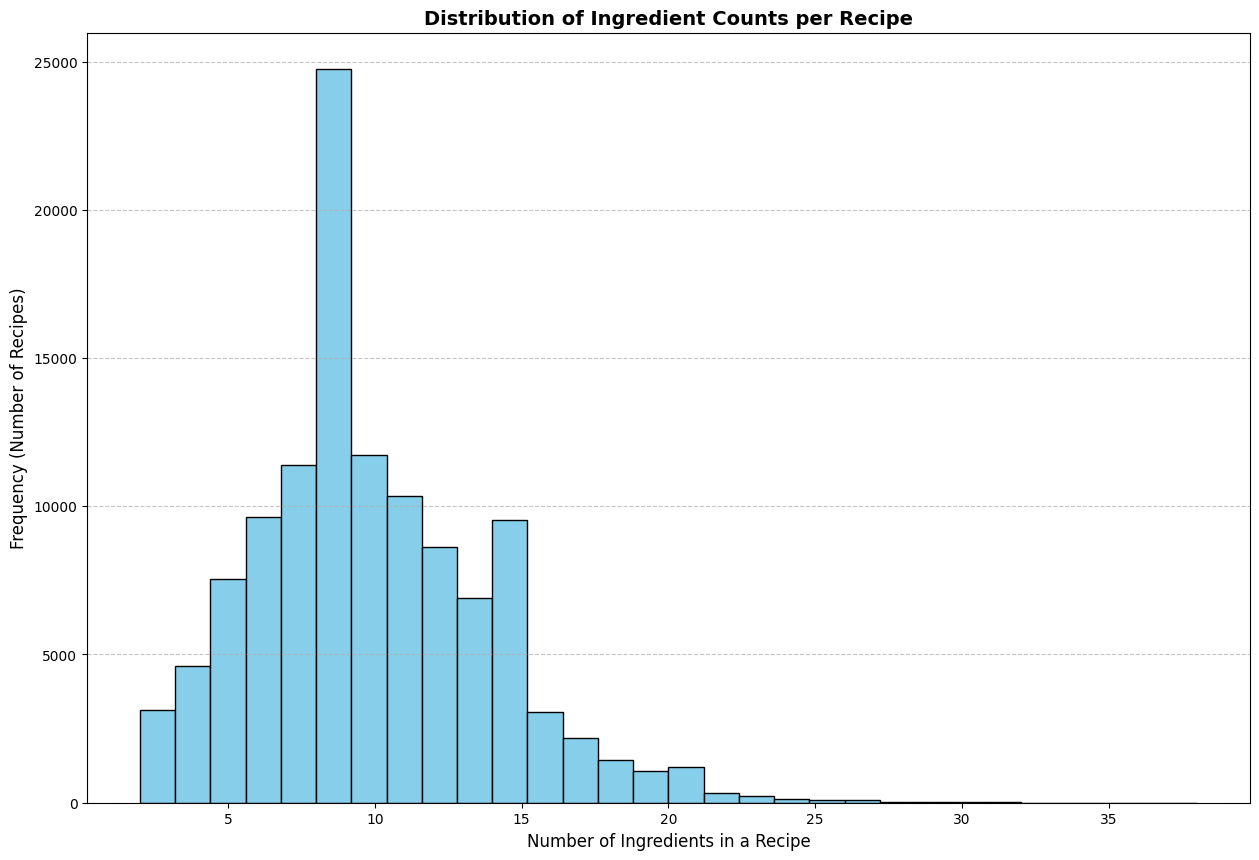

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# load the raw data
df_ing = pd.read_csv("../Datasets/RecipeID_Ing_ID.csv")

# group by recipe to get the total ingredient count for each
ingredient_counts = df_ing.groupby('recipe_no')['ing_id'].count()

# plot the histogram
plt.figure(figsize=(15, 10))
plt.hist(ingredient_counts, bins=30, color='skyblue', edgecolor='black')

# basic chart formatting
plt.title('Distribution of Ingredient Counts per Recipe', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ingredients in a Recipe', fontsize=12)
plt.ylabel('Frequency (Number of Recipes)', fontsize=12)
plt.grid(axis='y', alpha=0.75, linestyle='--')

plt.show()

### Exploratory Analysis: The Anatomy of a Recipe

Before diving into complex molecular overlap and flavor pairings, we first need to establish a baseline for our dataset. A fundamental question is: **What is the typical number of ingredients used in a global recipe?** Do human beings prefer simple 3-ingredient dishes, or highly complex 20-ingredient ones?

By aggregating our raw data, the resulting distribution reveals a clear pattern. The vast majority of recipes gravitate toward a "sweet spot" of about **8 to 9 ingredients**. As the ingredient count increases beyond 15, the frequency drops off sharply, demonstrating a classic right-skewed long-tail distribution. 

This gives us our first hint of a universal statistical law in culinary design: across different cultures, there is a natural human tendency to balance flavor complexity without making dishes overwhelmingly chaotic.